# Initial Image Data Preview

In [1]:
import pandas as pd
import json

In [2]:
first_file_num, last_file_num = 0, 10
df = pd.DataFrame()
for num in range(first_file_num, last_file_num + 1):
    with open(f"extracted_images/whole_{num}.json") as f:
        contents = f.read()
        file_json = json.loads(contents)
        file_df = pd.DataFrame(file_json)
    df = pd.concat([df, file_df], ignore_index=True)


In [3]:
df['book_id'] = df.id.apply(lambda x: x[:10])
df['page_num'] = df.id.apply(lambda x: x[10:15].strip('0'))

In [5]:
df.sample(10)

,id,labels,page_labels,scores,boxes,book_id,page_num
161223,014030010203390.TIF,12,"[12, 12, 1, 12]",0.990184,"[44.0911979675293, 1806.3883056640625, 2203.89...",0140300102,339
226887,062810030004230.TIF,3,"[3, 3, 2, 7, 3, 1, 2]",0.831898,"[899.1222534179688, 294.6745300292969, 944.950...",0628100300,423
70426,016210050102070.TIF,12,"[7, 12, 7, 12]",0.497385,"[18.696311950683594, 473.69940185546875, 1927....",0162100501,207
3492,023680060003130.TIF,1,"[1, 1, 3]",0.993234,"[53.0727424621582, 226.6192169189453, 1048.726...",0236800600,313
198621,013030020000270.TIF,1,"[1, 1, 1, 1]",0.971316,"[0.0, 1267.5662841796875, 1254.9921875, 1287.6...",0130300200,27
34525,039050010803030.TIF,1,[1],0.992549,"[112.27224731445312, 128.22576904296875, 1182....",0390500108,303
123705,093580030000100.TIF,7,"[15, 7, 1]",0.999338,"[69.07551574707031, 275.06011962890625, 983.79...",0935800300,1
144718,056490010103080.TIF,3,"[2, 2, 3, 3, 3, 1]",0.370001,"[1118.9791259765625, 1661.4669189453125, 1144....",0564900101,308
28999,017590120000010.TIF,1,[1],0.993085,"[327.0096435546875, 2009.3326416015625, 603.01...",0175901200,1
39586,069030010305080.TIF,2,"[2, 2, 3, 2, 3, 3, 3, 3, 6, 6, 6, 6, 1, 1, 1, ...",0.932037,"[1885.15625, 2584.72314453125, 1904.0490722656...",0690300103,508


### Label Meanings

1: ‘FI-HORIZONTAL RULE’, 

2: ‘FI-MISC. FUNCTIONAL ELEMENT’, 

3: ‘FI-VERTICAL RULE’, 

4: ‘O-LIBRARY STAMP’, 

5: ‘O-MISCELLANEOUS OTHER’, 

6: ‘PO-BORDER’, 

7: ‘PO-HEADPIECE’, 

8: ‘PO-OTHER PRINTER’S ORNAMENT’, 

9: ‘PO-PRINTERS DEVICE’, 

10: ‘PO-TAILPIECE’, 

11: ‘ILLU-FRONTISPIECE’, 

12: ‘ILLU-WOODCUT OR ENGRAVING’, 

13: ‘ILLU-OTHER’, 

14: ‘INIT-DECORATIVE INITIAL’, 

15: ‘INIT-FACTOTUM’

In [147]:
illustr = df[df.labels.isin([5, 8, 11, 12, 13])]
illustr_counts = illustr.book_id.value_counts().to_dict()

# Subsets

In [16]:
links = pd.read_csv("estc-data-unified/estc-eebo-ecco-links/idpairs_ecco_eebo_estc.csv")
works = pd.read_csv("estc-data-unified/estc-work-id/estc_work_id.tsv", sep='\t')
books = pd.read_csv("estc_student_edition.csv")
books["full_title"] = books.apply(lambda row: (str(row.title) + " " + str(row.remaining_title)).lower(), axis=1)

/var/folders/qn/_b4cqwl14qv5mxs65p_y4zhh0000gn/T/ipykernel_19264/4184046220.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  links = pd.read_csv("estc-data-unified/estc-eebo-ecco-links/idpairs_ecco_eebo_estc.csv")


In [ ]:
manual_heraldry_book_ids = ['R26135', 'R181126', 'R12114', 'N22559', 'N17450', 'T94010', 
                  'T166153', 'R32568', 'T100037', 'T113231', 'T117647', 'T134649', 
                  'T135745', 'T137070', 'T140947', 'T153613', 'T155315', 'T166154'
                  'T200312', 'T55579', 'T77924', 'T83445', 'T94006']

In [170]:
def get_heraldry_books_info(book_student_ids):
    get_estc_id = lambda student_id: links[links.estc_id_student_edition == student_id].estc_id.values[0]
    def get_document_id(estc_id, student_id): 
        link_data = links[links.estc_id == estc_id].document_id.values
        if not link_data.any():
            link_data = links[links.estc_id_student_edition == student_id].document_id.values
        if not link_data.any():
            return None
        return link_data[0]
    get_student_id = lambda estc_id: links[links.estc_id == estc_id].estc_id_student_edition.values[0] if estc_id in links.estc_id.values else None
    get_publ_year = lambda student_id: books[books.id == student_id].publication_year.values[0] if student_id in books.id.values else None
    get_pagecount = lambda student_id: books[books.id == student_id].pagecount.values[0] if student_id in books.id.values else None
    df = pd.DataFrame()
    for sid in book_student_ids:
        if sid not in links.estc_id_student_edition.values:
            continue
        estc_id = get_estc_id(sid)
        work_id = works[works.estc_id == estc_id]['work_id'].values[0] if estc_id in works.estc_id.values else None
        editions = works[works.work_id == work_id]['estc_id'].values if work_id else [estc_id]
        edition_doc_ids = [get_document_id(eid, sid) for eid in editions]
        edition_student_ids = [get_student_id(eid) for eid in editions]
        publ_years = [get_publ_year(sid) for sid in edition_student_ids]
        pagecounts = [get_pagecount(sid) for sid in edition_student_ids]
        illustr_num = [illustr_counts[str(did)] if str(did) in illustr_counts.keys() 
                       else illustr_counts[int(did)] if str(did).isnumeric() and int(did) in illustr_counts.keys() 
                       else None for did in edition_doc_ids]
        illustr_per_page = []
        for i, n in enumerate(illustr_num):
            try:
                ill_page = n / pagecounts[i]
            except:
                ill_page = None
            illustr_per_page.append(ill_page)
        work_df = pd.DataFrame({"work_id": work_id, "edition_estc_id": estc_id, "edition_document_id": edition_doc_ids, 
                                "edition_estc_id_student_edition": edition_student_ids, "publication_year": publ_years, 
                                "num_of_illustrations": illustr_num, "num_of_pages": pagecounts, "avg_illustrations_per_page": illustr_per_page})
        df = pd.concat([df, work_df], ignore_index=True)
    return df
    

In [138]:
keyword = 'Heraldry'
books = books[~books.subject_topic.isna()]
heraldry_books = books[books['subject_topic'].str.contains(keyword)]
heraldry_books_ids = heraldry_books.id.unique()

In [171]:
heraldry_books_info = get_heraldry_books_info(heraldry_books_ids)
heraldry_books_info

,work_id,edition_estc_id,edition_document_id,edition_estc_id_student_edition,publication_year,num_of_illustrations,num_of_pages,avg_illustrations_per_page
0,None,N001118,435700300,N1118,1793.0,None,118.0,NaN
1,None,N012198,109900100,N12198,1767.0,None,348.0,NaN
2,None,N017450,1274000200,N17450,1791.0,727,128.0,5.679688
3,None,N017665,1153000200,N17665,1795.0,38,325.0,0.116923
4,None,N020017,249200101,N20017,1789.0,None,2755.0,None
...,...,...,...,...,...,...,...,...
426,None,T094007,189600800,T94007,1771.0,None,332.0,None
427,None,T094008,535800800,T94008,1777.0,None,372.0,None
428,None,T094009,183100400,T94009,1787.0,None,388.0,None
429,None,T094010,515500400,T94010,1795.0,None,388.0,None


In [175]:
heraldry_books_info.to_csv("heraldry_books_info.csv")

In [6]:
import pandas as pd
heraldry_books_info = pd.read_csv("heraldry_books_info.csv", index_col=0)
heraldry_books_info["publication_year"].value_counts().sort_index()

1496.0    2
1566.0    2
1572.0    1
1595.0    2
1596.0    3
         ..
1793.0    4
1794.0    4
1795.0    4
1797.0    2
1800.0    1
Name: publication_year, Length: 85, dtype: int64

In [11]:
heraldry_books_w_imgs = heraldry_books_info[~heraldry_books_info["num_of_illustrations"].isna()][~heraldry_books_info["num_of_pages"].isna()]
heraldry_books_w_imgs.drop_duplicates(["edition_document_id", "publication_year", "num_of_illustrations", "num_of_pages"], inplace=True)

/var/folders/qn/_b4cqwl14qv5mxs65p_y4zhh0000gn/T/ipykernel_19264/500191446.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  heraldry_books_w_imgs = heraldry_books_info[~heraldry_books_info["num_of_illustrations"].isna()][~heraldry_books_info["num_of_pages"].isna()]


In [14]:
heraldry_books_w_imgs

,work_id,edition_estc_id,edition_document_id,edition_estc_id_student_edition,publication_year,num_of_illustrations,num_of_pages,avg_illustrations_per_page
2,NaN,N017450,1274000200,N17450,1791.0,727.0,128.0,5.679688
3,NaN,N017665,1153000200,N17665,1795.0,38.0,325.0,0.116923
6,NaN,N028522,1233500500,N28522,1739.0,108.0,18.0,6.000000
7,NaN,N032743,1097700100,N32743,1751.0,199.0,606.0,0.328383
12,X-heraldry in miniature,N33130,1705302200,N33130,1797.0,796.0,40.0,19.900000
13,X-heraldry in miniature,N33130,1014800300,T185743,1777.0,1092.0,44.0,24.818182
16,NaN,N003839,1262801200,N3839,1719.0,390.0,398.0,0.979899
160,15112-ducatus leodiensis or topography of anci...,T100187,1121900600,T142791,1715.0,159.0,671.0,0.236960
165,166933-peerage of great britain and ireland in...,T105741,1002600700,T105741,1793.0,74.0,202.0,0.366337
177,X-the heraldry of nature,T113785,1238001400,T182327,1785.0,96.0,96.0,1.000000


In [ ]:
import requests
import math
import os


def extract_imgs_from_book(row):
    doc_id = row['edition_document_id']
    page_num = int(row['num_of_pages']) if not math.isnan(row['num_of_pages']) else 0
    for p in range(1, page_num + 1):
        zero_separator = '000' if p < 10 else '00' if p < 100 else '0'
        img_url = f"https://oma-sivu.2.rahtiapp.fi/image/{doc_id}{zero_separator}{p}0"
        cur_dir = os.getcwd()
        book_dir =  os.path.join(cur_dir, f"images/{doc_id}")
        img_name =  os.path.join(book_dir, f"{doc_id}_{p}.png")
        try:
            img_data = requests.get(img_url).content
            if not os.path.exists(book_dir):
                os.makedirs(book_dir)
            with open(img_name, 'xb') as handler:
                handler.write(img_data)
            print(img_name)
        except Exception as e:
            print(e)
            continue

heraldry_books_w_imgs.apply(extract_imgs_from_book, axis=1)

In [ ]:
image_info_subset = df[df['book_id'].isin(heraldry_books_w_imgs.edition_document_id.values)]

# Move all images in a book to a separate folder
def separate_images(row):
    book = row.book_id
    page = row.page_num
    cur_dir = os.getcwd()
    book_dir = os.path.join(cur_dir, f"images/{book}")
    img_name = os.path.join(book_dir, f"{book}_{page}.png")
    subimg_dir = os.path.join(book_dir, f"selected_imgs")
    if os.path.exists(img_name):
        if not os.path.exists(subimg_dir):
            os.makedirs(subimg_dir)
        os.rename(img_name, os.path.join(subimg_dir, f"{book}_{page}.png"))

image_info_subset.apply(separate_images, axis=1)

385324      None
385325      None
385326      None
385327      None
385328      None
            ... 
15698626    None
15698627    None
15698628    None
15698629    None
15698630    None
Length: 12731, dtype: object

## Relevant books and images

In [ ]:
catalogues_ids = ['1274000200', '1014800300', '1097700100', '1121900300', 
                  '1121900600', '1153000200', '1221100200', '1233500500', 
                  '1238001400', '1262801200', '1266500200', '1712301301']

In [12]:
heraldry_books_w_imgs[heraldry_books_w_imgs["edition_document_id"].isin(catalogues_ids)]

,work_id,edition_estc_id,edition_document_id,edition_estc_id_student_edition,publication_year,num_of_illustrations,num_of_pages,avg_illustrations_per_page
2,NaN,N017450,1274000200,N17450,1791.0,727.0,128.0,5.679688
3,NaN,N017665,1153000200,N17665,1795.0,38.0,325.0,0.116923
6,NaN,N028522,1233500500,N28522,1739.0,108.0,18.0,6.000000
7,NaN,N032743,1097700100,N32743,1751.0,199.0,606.0,0.328383
13,X-heraldry in miniature,N33130,1014800300,T185743,1777.0,1092.0,44.0,24.818182
16,NaN,N003839,1262801200,N3839,1719.0,390.0,398.0,0.979899
160,15112-ducatus leodiensis or topography of anci...,T100187,1121900600,T142791,1715.0,159.0,671.0,0.236960
177,X-the heraldry of nature,T113785,1238001400,T182327,1785.0,96.0,96.0,1.000000
219,50365-grammar of heraldry or gentlemans vade m...,T117647,1221100200,T166154,1724.0,1571.0,250.0,6.284000
298,X-a new dictionary of heraldry,T134649,1266500200,T200312,1725.0,23.0,364.0,0.063187


In [14]:
import os

image_info_subset = df[df['book_id'].isin(catalogues_ids)]
for bid in catalogues_ids:
    cur_dir = os.getcwd()
    book_dir = os.path.join(cur_dir, f"images/{bid}/selected_imgs")
    dataset_dir = os.path.join(cur_dir, f"img_dataset")
    all_files = os.listdir(book_dir)
    for f in all_files:
        file_path = os.path.join(book_dir, f)
        os.popen(f'cp {file_path} {dataset_dir}')

In [15]:
heraldry_books_w_imgs[heraldry_books_w_imgs["edition_document_id"].isin(catalogues_ids)].to_csv("selected_catalogues.csv")

In [26]:
books.columns

Index(['id', 'title', 'remaining_title', 'document_type', 'subject_topic',
       'estc_language_vec', 'publication_year', 'publication_decade',
       'gatherings', 'width', 'height', 'area', 'pagecount', 'volcount',
       'paper', 'publication_place_752', 'country_752', 'longitude',
       'latitude', 'finalWorkField', 'WF_startDate', 'WF_endDate', 'actor_id',
       'is_organization', 'name_unified', 'actor_roles_all', 'full_title'],
      dtype='object')

In [20]:
works.head()

,work_id,estc_id
0,17273-monthly review or literary journal givin...,P1965
1,58177-julia or new eloisa series of original l...,N52582
2,8345-gentlemans magazine,P1955
3,45364-oeuvres dhorace en latin et en francois ...,T13700
4,11117-british merchant or commerce preservd in...,P2147


In [50]:
kearsley = works[works.work_id == works[works.estc_id == 'T167876'].work_id.values[0]].estc_id.values
links[links.estc_id.isin(kearsley)]

,estc_id,document_id,document_id_octavo,collection,estc_id_student_edition
19036,T121551,117500500,117500500,ecco,T121551
30782,T121269,186600401,186600401,ecco,T121269
30783,T121269,186600402,186600402,ecco,T121269
100112,T121279,764700201,764700201,ecco,T121279
100113,T121279,764700202,764700202,ecco,T121279
162301,N63315,1359700100,1359700100,ecco,N63315
189079,T167876,1587300601,1587300601,ecco,T167876
189080,T167876,1587300602,1587300602,ecco,T167876


In [52]:
books[books.id.isin(links[links.estc_id.isin(kearsley)].estc_id.values)].drop_duplicates(["id", "publication_year", "pagecount"])[["id", "title", "publication_year", "pagecount"]]

,id,title,publication_year,pagecount
153478,N63315,"Kearsley's complete peerage, of England, Scotl...",1791.0,483.0
576471,T121269,Kearsley's complete peerage,1799.0,632.0
576497,T121279,Kearsley's complete peerage,1796.0,584.0
577334,T121551,Kearsley's complete peerage,1794.0,531.0
685061,T167876,"Kearsley's complete peerage, of England, Scotl...",1800.0,548.0


In [ ]:
import requests
import os

relevant_fields = ['title', 'remaining_title', 'publication_year', 'pagecount']
#selected_books_df = pd.DataFrame()


def extract_imgs_from_additional_book(doc_id):
    estc_id = links[links.document_id == doc_id]
    if estc_id.empty:
        estc_id = links[links.document_id == int(doc_id)]
    estc_id = estc_id.estc_id_student_edition.values[0]
    work_id = works[works.estc_id == estc_id].work_id.values[0]
    book_info = books[books.id == estc_id].drop_duplicates(["id", "publication_year", "pagecount"])[relevant_fields]
    page_num = int(book_info["pagecount"].values[0])
    pub_year = int(book_info["publication_year"].values[0])
    title = book_info["title"].values[0]
    remaining_title = book_info["remaining_title"].values[0]
    
    for p in range(1, page_num + 1):
        zero_separator = '000' if p < 10 else '00' if p < 100 else '0'
        img_url = f"https://oma-sivu.2.rahtiapp.fi/image/{doc_id}{zero_separator}{p}0"
        cur_dir = os.getcwd()
        book_dir =  os.path.join(cur_dir, f"images/{doc_id}")
        img_name =  os.path.join(book_dir, f"{doc_id}_{p}.png")
        try:
            img_data = requests.get(img_url).content
            if not os.path.exists(book_dir):
                os.makedirs(book_dir)
            with open(img_name, 'wb') as handler:
                handler.write(img_data)
            print(img_name)
        except Exception as e:
            print(e)
            continue
    
    doc_df = pd.DataFrame({"work_id": [work_id], "edition_estc_id": [estc_id], "edition_document_id": [doc_id], 
                               "title": [title], "remaining_title": [remaining_title],
                               "publication_year": [pub_year], "num_of_pages": [page_num]})
    global selected_books_df
    selected_books_df = pd.concat([selected_books_df, doc_df], ignore_index=True)

In [ ]:
catalogues_with_supporters_ids = ['1014800300', '1097700100', '1121900300', '1221100200', '1238001400', '1274000200', '1712301301']
for doc in catalogues_with_supporters_ids:
    extract_imgs_from_additional_book(doc)

In [78]:
selected_books_df

,work_id,edition_estc_id,edition_document_id,title,remaining_title,publication_year,num_of_pages
0,X-heraldry in miniature,T185743,1014800300,Heraldry in miniature,"containing the arms, crests, supporters, and m...",1777,44
1,1576-british compendium,N32743,1097700100,The British compendium,"or, rudiments of honour. Vol. I. In two parts....",1751,606
2,X-heraldry in miniature,T83865,1121900300,Heraldry in miniature,"containing all the arms, crests, supporters, a...",1788,176
3,50365-grammar of heraldry or gentlemans vade m...,T166154,1221100200,The grammar of heraldry,"or, gentleman's vade mecum, In which are laid ...",1724,250
4,X-the heraldry of nature,T182327,1238001400,The heraldry of nature,"or, instructions for the King at Arms: compris...",1785,96
5,X-heraldry in miniature,N17450,1274000200,Heraldry in miniature,"containing all the arms, crests, supporters an...",1791,128
6,1576-british compendium,T77908,1712301301,"The British compendium: or, Rudiments of honour","Containing the titles, descents, marriages, is...",1723,560
7,3098-kearsleys complete peerage of england sco...,T121551,117500500,Kearsley's complete peerage,"of England, Scotland and Ireland; together wit...",1794,531
8,3098-kearsleys complete peerage of england sco...,T121269,186600401,Kearsley's complete peerage,"of England, Scotland and Ireland; together wit...",1799,632
9,3098-kearsleys complete peerage of england sco...,T121279,764700201,Kearsley's complete peerage,"of England, Scotland and Ireland; together wit...",1796,584


In [ ]:
selected_books_df.to_csv("selected_catalogues.csv")
# NB: All published in London
# 568 image

In [ ]:
additional_docs = ['117500500', '186600401', '764700201'] #'1359700100', '1587300601', '1587300602'

for doc in additional_docs:
    extract_imgs_from_additional_book(doc)

## Classification

In [7]:
import os
import pandas as pd
import numpy as np
from PIL import Image
from time import sleep

In [8]:
symbolism = pd.read_csv("animal_virtues.csv", sep=';')
classes = list(symbolism.Animal.unique())
classes

['Ape',
 'Ass',
 'Bear',
 'Beaver',
 'Boar',
 'Deer',
 'Antelope',
 'Bull',
 'Camel',
 'Cat',
 'Chameleon',
 'Rooster',
 'Crane',
 'Dog',
 'Dolphin',
 'Dove',
 'Dragon',
 'Eagle',
 'Elephant',
 'Falcon',
 'Fox',
 'Goat',
 'Goose',
 'Grasshopper',
 'Griffin',
 'Hare',
 'Hedgehog',
 'Horse',
 'Leopard',
 'Lion',
 'Owl',
 'Panther',
 'Pheasant',
 'Peacock',
 'Pelican',
 'Phoenix',
 'Raven',
 'Seahorse',
 'Sheep',
 'Small bird',
 'Snake',
 'Stork',
 'Squirrel',
 'Swan',
 'Tiger',
 'Tortoise',
 'Unicorn',
 'Weasel',
 'Wolf',
 'Human']

In [29]:
reduced_classes = ['Deer', 'Lion', 'Unicorn', 'Antelope', 'Eagle', 'Angel', 'Leopard',
                   'Dog', 'Griffin', 'Dragon', 'Bull', 'Human', 'Horse', 'Mermaid']

In [30]:
from transformers import CLIPProcessor, CLIPModel

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

In [31]:
batch_size = 32
probs = []
cur_dir = os.getcwd()
supporters_dir = os.path.join(cur_dir, f"extracted_images/split_supporters")
all_files = os.listdir(supporters_dir)

for i in range(0, len(all_files), batch_size):
  i_end = i + batch_size if i + batch_size < len(all_files) else len(all_files)
  batch_image_paths = all_files[i:i_end]
  batch_images = [Image.open(os.path.join(supporters_dir, path)) for path in batch_image_paths]
  inputs = processor(text=reduced_classes, images=batch_images, return_tensors="pt", padding=True)
  outputs = model(**inputs)
  batch_logits = outputs.logits_per_image
  batch_probs = batch_logits.softmax(dim=1)
  probs.extend(batch_probs.tolist())
  sleep(1)

In [32]:
def predict_class(probs_per_image):
  max_p = np.max(probs_per_image)
  max_id = np.argmax(probs_per_image)
  return reduced_classes[max_id], max_p

predictions = [predict_class(row) for row in probs]
pred_labels = [pr[0] for pr in predictions]
pred_probs = [pr[1] for pr in predictions]

detected_animals = pd.DataFrame({"filename": all_files, "label": pred_labels, "probability": pred_probs})
detected_animals

,filename,label,probability
0,764700201_61_6_right.png,Lion,0.239001
1,1121900300_31_8_right.png,Eagle,0.404374
2,1587300602_26_2_right.png,Eagle,0.175896
3,1274000200_114_3_right.png,Human,0.312331
4,1121900300_48_5_right.png,Human,0.474462
...,...,...,...
6239,764700201_40_2_right.png,Bull,0.256195
6240,1121900300_49_4_right.png,Horse,0.231735
6241,1359700100_54_8_right.png,Griffin,0.332577
6242,117500500_75_3_right.png,Lion,0.210276


In [37]:
detected_animals.to_csv("clip_results_reduced_labels.csv")

In [33]:
detected_animals.label.value_counts()

Griffin     1512
Lion        1283
Eagle        877
Human        681
Dragon       424
Dog          418
Horse        299
Unicorn      261
Bull         225
Leopard       88
Mermaid       61
Angel         60
Deer          42
Antelope      13
Name: label, dtype: int64

<AxesSubplot:>

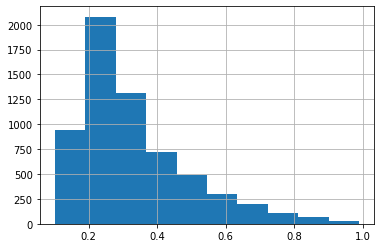

In [34]:
detected_animals.probability.hist()

In [36]:
detected_animals[detected_animals.probability > 0.5] #.label.value_counts()

,filename,label,probability
25,186600401_90_6_left.png,Griffin,0.748448
26,1587300602_3_2_left.png,Angel,0.723803
31,1587300601_31_4_left.png,Lion,0.708330
35,1587300602_3_3_left.png,Lion,0.623318
37,1587300601_31_5_left.png,Eagle,0.590607
...,...,...,...
6209,1359700100_277_3_left.png,Lion,0.516540
6215,1359700100_277_2_left.png,Lion,0.748147
6221,1587300602_17_1_left.png,Eagle,0.644234
6230,1587300601_45_7_right.png,Bull,0.557417


# Frequency Counts

In [51]:
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

import warnings
warnings.filterwarnings('ignore')

In [150]:
def get_plot(chart_type, title, data, range_x=None, range_y=None,
              x=None, y=None, group=None, category_orders=None, text=None,
              nbins=None, orient=None, barmode='relative', extra_hist=None,
              x_name=None, y_name=None, hovertemplate=None, hover_titles=[],
              color_list=None, color_dict=None, color_scale=None, template="plotly_white",
              height=400, width=800):

  # Base charts
  if chart_type == 'scatter':
    fig = px.scatter(data, x=x, y=y, color=group, size=[10] * data.shape[0],
                      range_x=range_x, range_y=range_y,
                      color_discrete_sequence=color_list,
                      color_discrete_map=color_dict,
                      template=template, title=title)

  if chart_type == 'bar':
    fig = px.bar(data, x=x, y=y, color=group, text=text,
                orientation=orient, barmode=barmode,
                category_orders=category_orders,
                color_discrete_sequence=color_list,
                color_discrete_map=color_dict,
                color_continuous_scale=color_scale,
                template=template,
                title=title)

  if chart_type == 'hist':
    fig = px.histogram(data, x=x, y=y, color=group, nbins=nbins,
                       barmode=barmode, histnorm='probability',
                       opacity=0.7, color_discrete_sequence=color_list,
                       color_discrete_map=color_dict, marginal=extra_hist,
                       template=template, title=title)
    
  if chart_type == 'box':
    fig = px.box(data, x=x, y=y, color=group,
                 category_orders=category_orders,
                 color_discrete_sequence=color_list,
                 color_discrete_map=color_dict,
                 template=template,
                 title=title)
  
  if chart_type == 'treemap':
    fig = px.treemap(data, path=x, values=y, color=group,
                 color_discrete_sequence=color_list,
                 color_discrete_map=color_dict,
                 template=template,
                 title=title)
    fig.data[0].textinfo = 'label+value'
    fig.data[0].texttemplate='<b>%{label}</b><br>%{value:.2r}'

  # Updates
  fig.update_xaxes(title=x_name)
  fig.update_yaxes(title=y_name)

  fig.update_traces(hovertemplate=hovertemplate)
  if not hovertemplate:
    fig.update_traces(hoverinfo='skip')

  for id, val in enumerate(hover_titles):
    fig.data[id].name = ""
    fig.data[id].hovertemplate = val + '<br>' + fig.data[id].hovertemplate

  fig.update_layout(height=height, width=width, font_family="Futura", title_font_size=16,
                    showlegend=False, coloraxis_showscale=False,
                    plot_bgcolor="#FFFFFF", paper_bgcolor="#FFFFFF")
  return fig

In [117]:
annotations = pd.read_csv("annotations_detailed.csv")
annotations.drop_duplicates('image', inplace=True)
annotations['image'] = annotations['image'].apply(lambda x: x.replace('http://127.0.0.1:8000/', '').strip('.png'))
annotations = annotations[['image', 'label']][~annotations.label.isin(['nothing', 'unclear', 'hybrid_other'])]
annotations['label'] = annotations.label.apply(lambda x: x.replace('_', ' ').capitalize() if isinstance(x, str) else None)

In [118]:
annotations['doc_id'] = annotations.image.apply(lambda x: int(x.split('_')[0]))
annotations['page_num'] = annotations.image.apply(lambda x: x.split('_')[1])
annotations['picture_num'] = annotations.image.apply(lambda x: x.split('_')[2])
annotations['position'] = annotations.image.apply(lambda x: x.split('_')[3])
annotations['heraldry_id'] = annotations.image.apply(lambda x: x.strip('_left').strip('_right'))

### Overall counts

In [151]:
animal_counts = annotations.label.value_counts(normalize=True).sort_values(ascending=True).reset_index()

plot = get_plot(chart_type='bar', title=f"<br><span style='color:{'#567755'}'><b>Animals as heraldry supporters.</b> All titles together</span>",
                data=animal_counts, x='proportion', y='label',
                x_name="proportion", y_name="", color_list=['#929ADD'],
                hovertemplate="%{x}<br>%{y}", height=800)

plot.show()

### Averaged per title

In [119]:
catalogue_info = pd.read_csv(("selected_catalogues.csv"), index_col=0)
unique_work_ids = catalogue_info[['work_id', 'edition_document_id']].rename(columns={'edition_document_id': 'doc_id'})
annotations = annotations.merge(unique_work_ids, on='doc_id', how='left')

In [263]:
labels_per_work = annotations.groupby('work_id')['label'].value_counts(normalize=True, sort=True).reset_index()
labels_per_work

,work_id,label,proportion
0,1576-british compendium,Lion,0.265018
1,1576-british compendium,Human,0.106007
2,1576-british compendium,Eagle,0.072438
3,1576-british compendium,Griffin,0.070671
4,1576-british compendium,Dog talbot,0.061837
...,...,...,...
99,X-the heraldry of nature,Boar,0.009615
100,X-the heraldry of nature,Bull,0.009615
101,X-the heraldry of nature,Dragon,0.009615
102,X-the heraldry of nature,Eagle,0.009615


In [264]:
plot = get_plot(chart_type='bar', title=f"<br><span style='color:{'#567755'}'><b>Animals as heraldry supporters</b>. Comparison of titles</span>",
                data=labels_per_work, x='proportion', y='label',
                x_name="proportion", y_name="", group="work_id",
                hovertemplate="%{x}<br>%{y}", barmode='relative', height=1000)

plot.show()

In [156]:
for widx in labels_per_work.work_id.unique():
    plot = get_plot(chart_type='treemap', title=f"<br><span style='color:{'#567755'}'><b>Animals as heraldry supporters: {widx[:40]}</b></span>",
                data=labels_per_work[labels_per_work.work_id == widx], x=['label'], y='proportion')

    plot.show()

In [ ]:
avg_of_avg = labels_per_work.groupby('label').mean('proportion').reset_index().sort_values('proportion', ascending=True)
avg_of_avg

,label,proportion
11,Elephant,0.001421
5,Chicken,0.001797
14,Hare,0.002069
2,Beaver,0.002831
6,Doe deer,0.003094
28,Water horse,0.003525
19,Lion fish,0.004029
12,Goat,0.004570
20,Monkey,0.005598
21,Ostrich,0.006079


In [157]:
plot = get_plot(chart_type='bar', title=f"<br><span style='color:{'#567755'}'><b>Animals as heraldry supporters.</b> Averaged per title</span>",
                data=avg_of_avg, x='proportion', y='label',
                x_name="proportion", y_name="", color_list=['#929ADD'],
                hovertemplate="%{x}<br>%{y}", height=800)

plot.show()

### Supporter pairs

In [178]:
animal_pairs = annotations.pivot(columns='position', index=['work_id', 'doc_id', 'heraldry_id'], values='label').reset_index()
animal_pairs

position,work_id,doc_id,heraldry_id,left,right
0,1576-british compendium,1097700100,1097700100_11_1,Unicorn,Bull
1,1576-british compendium,1097700100,1097700100_11_2,Unicorn,Stag deer
2,1576-british compendium,1097700100,1097700100_12_1,Lion,Dog greyhound
3,1576-british compendium,1097700100,1097700100_12_2,Lion,Dog greyhound
4,1576-british compendium,1097700100,1097700100_13_1,Dog talbot,Dragon
...,...,...,...,...,...
2998,X-the heraldry of nature,1238001400,1238001400_9_4,Human,Human
2999,X-the heraldry of nature,1238001400,1238001400_9_5,Human,Dragon
3000,X-the heraldry of nature,1238001400,1238001400_9_6,Human,Human
3001,X-the heraldry of nature,1238001400,1238001400_9_7,Human,Human


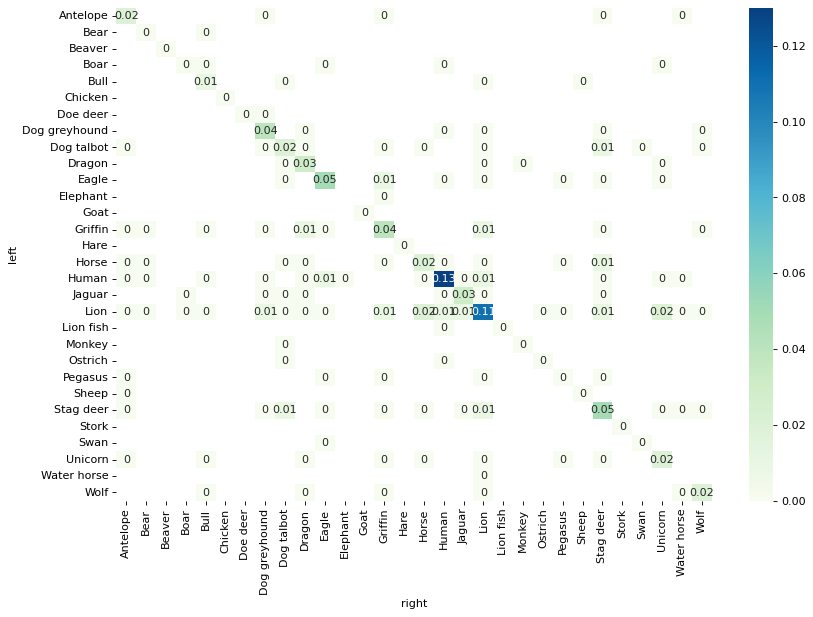

In [177]:
pair_matrix = (animal_pairs.groupby(['left', 'right']).size() / animal_pairs.shape[0]).apply(lambda x: round(x, 2)).unstack(fill_value=None)

plt.figure(figsize=(12, 8), dpi=80)
sns.heatmap(pair_matrix, annot=True, cmap="GnBu", fmt="g")
plt.show()

In [186]:
animal_pairs_title_avg = animal_pairs.groupby('work_id')[['left', 'right']].value_counts(normalize=True, ascending=True).reset_index()
animal_pairs_title_avg

,work_id,left,right,proportion
0,1576-british compendium,Antelope,Dog greyhound,0.003610
1,1576-british compendium,Boar,Bull,0.003610
2,1576-british compendium,Dog greyhound,Wolf,0.003610
3,1576-british compendium,Dog talbot,Antelope,0.003610
4,1576-british compendium,Dog talbot,Dog greyhound,0.003610
...,...,...,...,...
337,X-the heraldry of nature,Jaguar,Dog greyhound,0.021739
338,X-the heraldry of nature,Jaguar,Human,0.021739
339,X-the heraldry of nature,Unicorn,Unicorn,0.021739
340,X-the heraldry of nature,Horse,Horse,0.043478


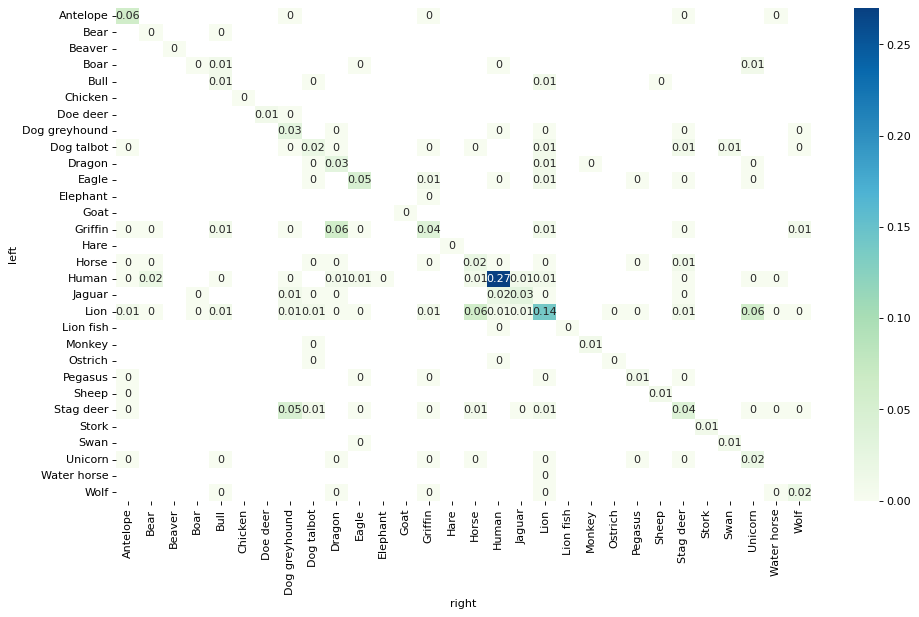

In [202]:
pair_matrix = animal_pairs_title_avg.groupby(['left', 'right']).mean('proportion').apply(lambda x: round(x, 2)).unstack(fill_value=None).proportion

plt.figure(figsize=(14, 8), dpi=80)
sns.heatmap(pair_matrix, annot=True, cmap="GnBu", fmt="g")
plt.show()

## Characteristics

In [ ]:
virtues = pd.read_csv("animal_virtues.csv", sep=';')
virtues = virtues[virtues.Animal.isin(annotations.label.unique())][virtues.Animal != 'Human']
virtues['Symbolism'] = virtues['Symbolism'].apply(lambda x: x.split(', ') if isinstance(x, str) else None)
virtues = virtues.explode('Symbolism')
virtues

,Animal,Symbolism
0,Monkey,foolishness
0,Monkey,frivolity
0,Monkey,deceit
2,Bear,courage
2,Bear,strength
...,...,...
51,Wolf,fierceness
51,Wolf,treachery
51,Wolf,cruelty
51,Wolf,deception


In [ ]:
virtues_freq = virtues.merge(avg_of_avg, how='left', left_on='Animal', right_on='label')
virtues_freq.drop('label', axis=1, inplace=True)
virtues_freq = virtues_freq.groupby('Symbolism').sum('proportion').reset_index().sort_values('proportion', ascending=True)
virtues_freq

,Symbolism,proportion
0,ambition for praise,0.001421
41,ingenuity,0.001421
15,docility,0.001421
43,intelligence,0.001421
90,virtue,0.001421
...,...,...
73,royalty,0.260754
53,majesty,0.260754
46,justice,0.269448
4,courage,0.309455


In [ ]:
plot = get_plot(chart_type='bar', title=f"<br><span style='color:{'#567755'}'><b>Heraldry animal symbolism.</b> Averaged per title</span>",
                data=virtues_freq, x='proportion', y='Symbolism',
                x_name="proportion", y_name="", color_list=['#929ADD'],
                hovertemplate="%{x}<br>%{y}", height=1600)

plot.show()

## Case Study

In [205]:
kearsley_401 = pd.read_csv("nobility_classes/book_186600401.csv")
kearsley_401

,book_id,image_name,kingdom,rank
0,186600401,186600401_100_1_left,ir,earl
1,186600401,186600401_100_1_right,ir,earl
2,186600401,186600401_100_2_left,ir,earl
3,186600401,186600401_100_2_right,ir,earl
4,186600401,186600401_100_3_left,ir,earl
...,...,...,...,...
1043,186600401,186600401_99_6_right,ir,earl
1044,186600401,186600401_99_7_left,ir,earl
1045,186600401,186600401_99_7_right,ir,earl
1046,186600401,186600401_99_8_left,ir,earl


In [209]:
kearsley_401_labels = annotations[annotations.doc_id == 186600401].merge(kearsley_401, left_on='image', right_on='image_name', how='left')
kearsley_401_labels.drop(['book_id', 'work_id', 'doc_id', 'image_name'], axis=1, inplace=True)
kearsley_401_labels

,image,label,page_num,picture_num,position,heraldry_id,kingdom,rank
0,186600401_100_1_left,Dragon,100,1,left,186600401_100_1,ir,earl
1,186600401_100_1_right,Unicorn,100,1,right,186600401_100_1,ir,earl
2,186600401_100_2_left,Eagle,100,2,left,186600401_100_2,ir,earl
3,186600401_100_2_right,Eagle,100,2,right,186600401_100_2,ir,earl
4,186600401_100_3_left,Jaguar,100,3,left,186600401_100_3,ir,earl
...,...,...,...,...,...,...,...,...
934,186600401_99_6_left,Eagle,99,6,left,186600401_99_6,ir,earl
935,186600401_99_6_right,Eagle,99,6,right,186600401_99_6,ir,earl
936,186600401_99_7_right,Horse,99,7,right,186600401_99_7,ir,earl
937,186600401_99_8_left,Jaguar,99,8,left,186600401_99_8,ir,earl


### Kingdoms

In [ ]:
kingdom_label_counts = kearsley_401_labels.groupby('kingdom')['label'].value_counts(normalize=True, sort=True).reset_index()
kingdom_label_counts

,kingdom,label,proportion
69,sc,Sheep,0.006579
68,sc,Boar,0.006579
67,sc,Wolf,0.013158
66,sc,Ostrich,0.013158
65,sc,Jaguar,0.013158
...,...,...,...
4,en,Griffin,0.064646
3,en,Eagle,0.068687
2,en,Stag deer,0.084848
1,en,Human,0.147475


In [257]:
plot = get_plot(chart_type='bar', title=f"<br><span style='color:{'#567755'}'><b>Animals as heraldry supporters in Kearsley's Catalogue</b>. Comparison of kingdoms</span>",
                data=kingdom_label_counts, x='proportion', y='label',
                x_name="proportion", y_name="", group="kingdom",
                hovertemplate="%{x}<br>%{y}", barmode='relative', height=1000)

plot.show()

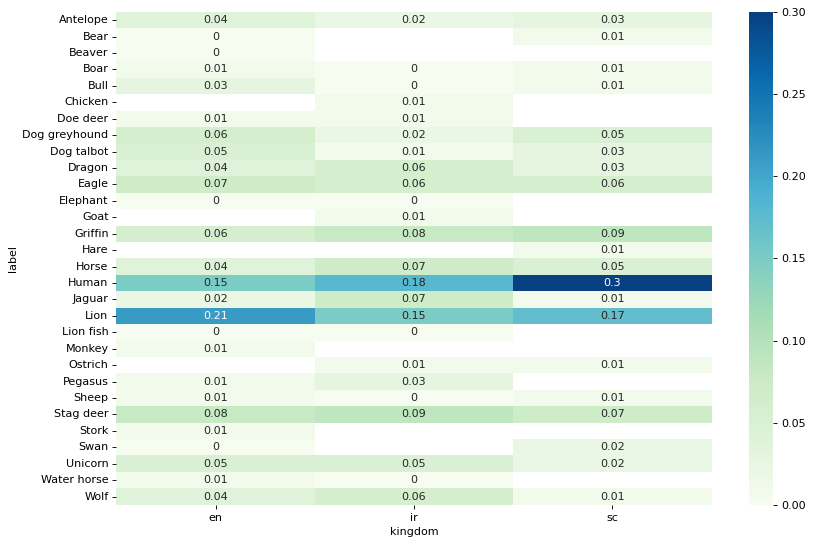

In [270]:
kingdom_label_matrix = kingdom_label_counts.pivot(columns='kingdom', index='label', values='proportion').apply(lambda x: round(x, 2))

plt.figure(figsize=(12, 8), dpi=80)
sns.heatmap(kingdom_label_matrix, annot=True, cmap="GnBu", fmt="g")
plt.show()

### Nobility Ranks

In [265]:
rank_label_counts = kearsley_401_labels.groupby('rank')['label'].value_counts(normalize=True, sort=True).reset_index()
rank_label_counts

,rank,label,proportion
0,baron,Human,0.238532
1,baron,Lion,0.171254
2,baron,Stag deer,0.079511
3,baron,Griffin,0.073394
4,baron,Horse,0.070336
...,...,...,...
101,viscount,Lion fish,0.016129
102,viscount,Monkey,0.016129
103,viscount,Water horse,0.016129
104,viscount,Antelope,0.008065


In [266]:
plot = get_plot(chart_type='bar', title=f"<br><span style='color:{'#567755'}'><b>Animals as heraldry supporters in Kearsley's Catalogue</b>. Comparison of nobility ranks</span>",
                data=rank_label_counts, x='proportion', y='label',
                x_name="proportion", y_name="", group="rank",
                hovertemplate="%{x}<br>%{y}", barmode='relative', height=1000)

plot.show()

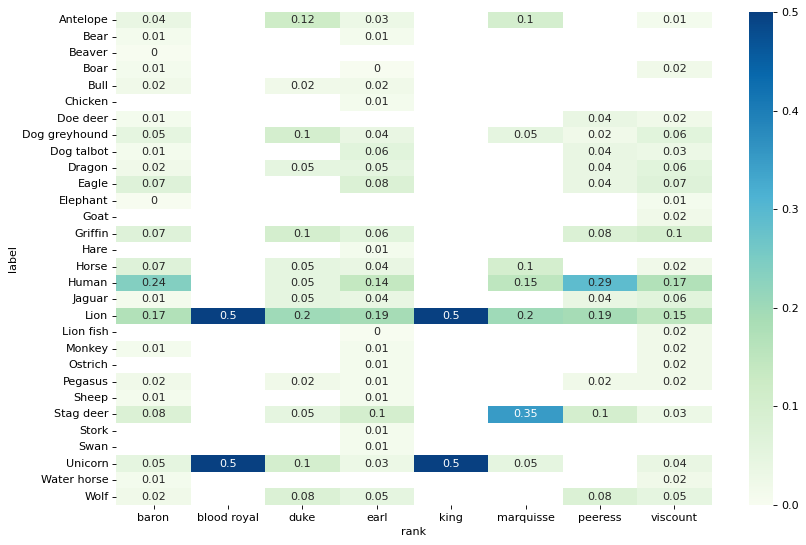

In [269]:
rank_label_matrix = rank_label_counts.pivot(columns='rank', index='label', values='proportion').apply(lambda x: round(x, 2))

plt.figure(figsize=(12, 8), dpi=80)
sns.heatmap(rank_label_matrix, annot=True, cmap="GnBu", fmt="g")
plt.show()

### Characteristics

In [304]:
rank_virtues_freq = virtues.merge(rank_label_counts, how='outer', left_on='Animal', right_on='label')
rank_virtues_freq.drop('label', axis=1, inplace=True)
rank_virtues_freq = rank_virtues_freq.groupby(['rank', 'Symbolism']).sum('proportion').reset_index().sort_values('proportion', ascending=True).rename(columns={'Symbolism': 'symbolism'})
rank_virtues_freq

,rank,symbolism,proportion
198,earl,sensuality,0.002740
0,baron,ambition for praise,0.003058
47,baron,mercy,0.003058
13,baron,docility,0.003058
80,baron,virtue,0.003058
...,...,...,...
88,blood royal,royalty,0.500000
90,blood royal,strength,1.000000
210,king,courage,1.000000
218,king,strength,1.000000


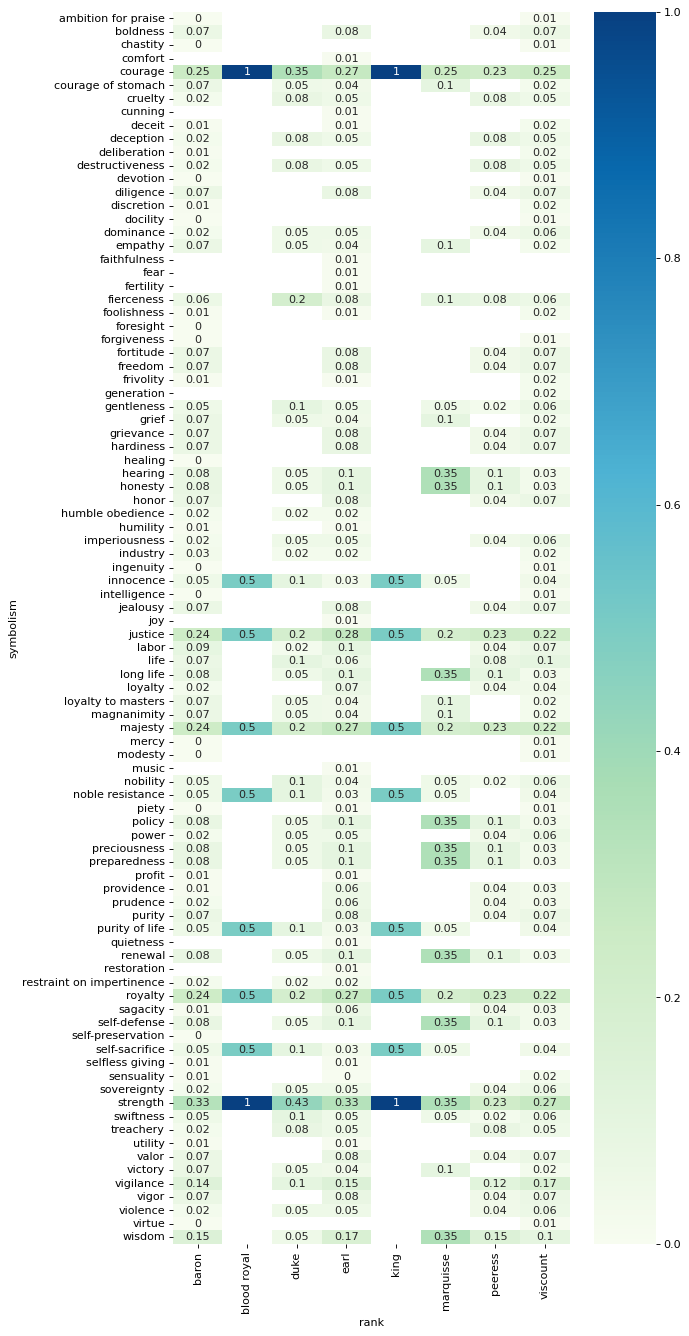

In [306]:
rank_virtue_matrix = rank_virtues_freq.pivot(columns='rank', index='symbolism', values='proportion').apply(lambda x: round(x, 2))

plt.figure(figsize=(8, 20), dpi=80)
sns.heatmap(rank_virtue_matrix, annot=True, cmap="GnBu", fmt="g")
plt.show()